# Daily S&P 500 Direction Prediction — Classification Models

Predicting whether SPY goes **up or down** the next day from the same-day returns of 12 large constituents.
Three models (XGBoost, LightGBM, Transformer), each evaluated with walk-forward validation against an "always up" baseline, tuned with Optuna and tracked in MLflow.

## Imports and environment setup

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import mlflow
import optuna
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("spy_direction_prediction")
print("MLflow tracking URI:", mlflow.get_tracking_uri())
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MKL_THREADING_LAYER"] = "GNU"

import numpy as np
import torch
torch.set_num_threads(1)


sns.set_theme(style="whitegrid")

/Users/bartox/Desktop/dev/ML/ml_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI: sqlite:///mlflow.db


## Data loading
12 large-cap tickers as features, SPY as the target.

In [ ]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]
data_path = "../Data_clean/Stocks clean"
sp500_path = "../Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [3]:
# Load each ticker's closing price into a single combined table (one column per stock)
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col="Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

# Add SPY closing price as the prediction target
sp500_df = pd.read_csv(sp500_path, index_col="Date", parse_dates=True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]

In [4]:
df = df.sort_index()

# Trim to the common date range where all tickers have data
start_date = '2005-02-25'
df = df.loc[start_date:]

df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-25,5.6975,21.173,92.935,34.99,8.9161,30.812,44.109,100.420,50.892,43.50,53.894,17.546,105.79
2005-02-28,5.7449,21.099,93.995,35.18,8.9625,30.463,43.980,99.241,50.937,43.52,53.390,17.456,105.08
2005-03-01,5.6987,21.199,93.030,35.39,8.9439,30.911,44.384,100.350,49.964,43.22,54.244,17.649,105.62
2005-03-02,5.6499,21.182,92.590,35.50,8.6843,30.828,43.904,100.090,50.433,43.25,54.496,17.555,105.57
2005-03-03,5.3518,21.109,93.505,35.65,8.5635,30.847,43.680,99.790,50.735,42.97,54.324,17.611,105.61


## Features and target

Features: same-day percentage returns of the 12 stocks.
Target: the **next-day** SPY return — `shift(-1)` moves tomorrow's return onto today's row, so we predict the future from the present (no look-ahead leakage). The continuous return is later turned into an up/down label for classification.

In [5]:
# Features: same-day returns of the 12 stocks
returns_df = df[core_stocks].pct_change()

# Target: next-day SPY return. shift(-1) aligns tomorrow's return with today's features,
# so the model predicts the future from the present (no look-ahead leakage).
# Later converted to a binary up/down label.
returns_df['spy'] = df['spy'].pct_change().shift(-1)

returns_df = returns_df.loc["2005-02-28":]  # drop the first row (NaN from pct_change)
returns_df = returns_df.dropna()            # drop the last row (NaN from shift(-1))
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-28,0.008319,-0.003495,0.011406,0.005430,0.005204,-0.011327,-0.002925,-0.011741,0.000884,0.000460,-0.009352,-0.005129,0.005139
2005-03-01,-0.008042,0.004740,-0.010267,0.005969,-0.002075,0.014706,0.009186,0.011175,-0.019102,-0.006893,0.015996,0.011056,-0.000473
2005-03-02,-0.008563,-0.000802,-0.004730,0.003108,-0.029025,-0.002685,-0.010815,-0.002591,0.009387,0.000694,0.004646,-0.005326,0.000379
2005-03-03,-0.052762,-0.003446,0.009882,0.004225,-0.013910,0.000616,-0.005102,-0.002997,0.005988,-0.006474,-0.003156,0.003190,0.012499
2005-03-04,0.024384,0.000000,-0.005936,0.005610,-0.004356,0.013453,0.009615,0.019341,0.008121,0.009542,0.014837,0.010732,0.000374


## Train/test split

Time-ordered split (`shuffle=False`) — train on the past, test on the future.
Shuffling would leak future information into training and inflate the results.

In [6]:
X = returns_df[core_stocks]
y = returns_df["spy"]

# shuffle=False keeps chronological order: train on earlier data, test on later data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## XGBoost (walk-forward + MLflow)

Gradient-boosted trees predicting up/down direction. Trained per fold, logged to MLflow.
The baseline here is the share of "up" days — i.e. the accuracy of always guessing "up". A model only adds value if it beats that.

In [7]:
tscv = TimeSeriesSplit(n_splits=5)

xgb_params = dict(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_scores = []

# One MLflow run per model; per-fold metrics logged with step=fold to get a curve in the UI
with mlflow.start_run(run_name="xgboost_walkforward"):
    mlflow.set_tag("model", "xgboost")
    mlflow.log_params(xgb_params)
    mlflow.log_param("n_splits", 5)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # Turn the continuous return into a binary label: 1 = up, 0 = down
        y_tr_cls = (y_tr > 0).astype(int)
        y_te_cls = (y_te > 0).astype(int)

        m = xgb.XGBClassifier(**xgb_params)
        m.fit(X_tr, y_tr_cls)
        pred = m.predict(X_te)

        acc = accuracy_score(y_te_cls, pred)
        baseline = y_te_cls.mean()   # share of "up" days = accuracy of always predicting "up"
        xgb_scores.append(acc)

        mlflow.log_metric("fold_accuracy", acc, step=fold)
        mlflow.log_metric("fold_baseline", baseline, step=fold)
        mlflow.log_metric("fold_diff", acc - baseline, step=fold)
        print(f"Fold {fold}:  accuracy={acc:.4f}  |  baseline={baseline:.4f}  |  diff={acc - baseline:+.4f}")

    mlflow.log_metric("mean_accuracy", float(np.mean(xgb_scores)))
    mlflow.log_metric("std_accuracy", float(np.std(xgb_scores)))
    print(f"\nXGB walk-forward:  mean={np.mean(xgb_scores):.4f}  std={np.std(xgb_scores):.4f}")

Fold 1:  accuracy=0.5036  |  baseline=0.5163  |  diff=-0.0127
Fold 2:  accuracy=0.5199  |  baseline=0.5707  |  diff=-0.0507
Fold 3:  accuracy=0.5598  |  baseline=0.5525  |  diff=+0.0072
Fold 4:  accuracy=0.5326  |  baseline=0.5471  |  diff=-0.0145
Fold 5:  accuracy=0.5362  |  baseline=0.5507  |  diff=-0.0145

XGB walk-forward:  mean=0.5304  std=0.0186


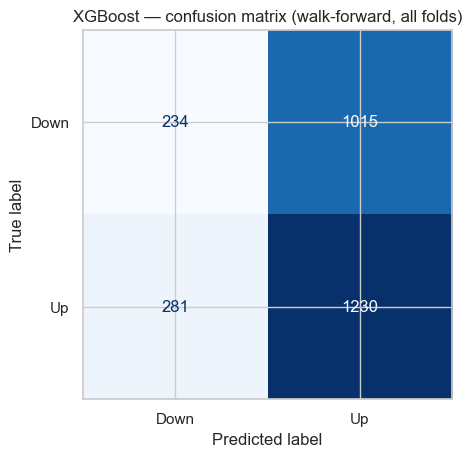

Predicted 'Up' share: 0.813
Actual    'Up' share: 0.547


In [8]:
# Collect predictions across all folds, then build one confusion matrix over everything
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    y_tr_cls = (y_tr > 0).astype(int)
    y_te_cls = (y_te > 0).astype(int)
    m = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(X_tr, y_tr_cls)
    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(m.predict(X_te).tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Blues", colorbar=False)
plt.title("XGBoost — confusion matrix (walk-forward, all folds)")
plt.show()

# Compare how often the model says "up" vs how often "up" actually happens — reveals if it just defaults to the majority class
print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

The "Down" column is almost empty — the model rarely predicts a down day.
Its predicted "up" share is far higher than the actual one, meaning it mostly defaults to the majority class instead of detecting direction. That's why its ~53% accuracy isn't skill: it's just copying the class distribution.

## Hyperparameter tuning with Optuna (LightGBM)

Optuna searches the hyperparameter space, with every trial logged to MLflow as a nested run.
**Key choice:** we optimize `accuracy − baseline` (the edge over "always up"), not raw accuracy — otherwise Optuna would "win" by landing on folds with a high up-share, rewarding luck instead of skill. Each trial is scored on the full 5-fold walk-forward.

In [9]:
def lgbm_objective(trial):
    """One Optuna trial: evaluate a hyperparameter set on the full walk-forward.

    Returns the mean (accuracy − baseline) across folds — the metric Optuna maximizes.
    """
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        num_leaves=trial.suggest_int("num_leaves", 4, 64),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        random_state=42,
        verbose=-1,
    )
    diffs = []
    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        y_tr_cls = (y_tr > 0).astype(int)
        y_te_cls = (y_te > 0).astype(int)
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr_cls)
        # Edge over baseline, averaged across folds — what we actually care about
        diffs.append(accuracy_score(y_te_cls, m.predict(X_te)) - y_te_cls.mean())
    mean_diff = float(np.mean(diffs))

    # Log each trial as a nested run so the full search is browsable in MLflow
    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True):
        mlflow.set_tag("model", "lightgbm_optuna")
        mlflow.log_params(params)
        mlflow.log_metric("mean_diff", mean_diff)
    return mean_diff

with mlflow.start_run(run_name="lgbm_optuna_study"):
    study_lgbm = optuna.create_study(direction="maximize")
    study_lgbm.optimize(lgbm_objective, n_trials=30)
    mlflow.log_params(study_lgbm.best_params)
    mlflow.log_metric("best_mean_diff", study_lgbm.best_value)

print("LGBM best mean_diff:", round(study_lgbm.best_value, 4))
print("LGBM best params:", study_lgbm.best_params)

[I 2026-06-19 21:02:19,852] A new study created in memory with name: no-name-5e2b709c-3279-422e-a8c0-512c11d11e55
[I 2026-06-19 21:02:21,158] Trial 0 finished with value: -0.03224637681159419 and parameters: {'n_estimators': 255, 'learning_rate': 0.2020251997548691, 'num_leaves': 47, 'max_depth': 4, 'subsample': 0.7161163374219139, 'colsample_bytree': 0.8149725525242852}. Best is trial 0 with value: -0.03224637681159419.
[I 2026-06-19 21:02:22,499] Trial 1 finished with value: -0.0028985507246376717 and parameters: {'n_estimators': 129, 'learning_rate': 0.0056137664848727375, 'num_leaves': 26, 'max_depth': 6, 'subsample': 0.7118395558371515, 'colsample_bytree': 0.7552793793347141}. Best is trial 1 with value: -0.0028985507246376717.
[I 2026-06-19 21:02:23,341] Trial 2 finished with value: -0.021376811594202884 and parameters: {'n_estimators': 395, 'learning_rate': 0.13476919444747573, 'num_leaves': 54, 'max_depth': 2, 'subsample': 0.8742483985257702, 'colsample_bytree': 0.8079069042267

LGBM best mean_diff: -0.0029
LGBM best params: {'n_estimators': 129, 'learning_rate': 0.0056137664848727375, 'num_leaves': 26, 'max_depth': 6, 'subsample': 0.7118395558371515, 'colsample_bytree': 0.7552793793347141}


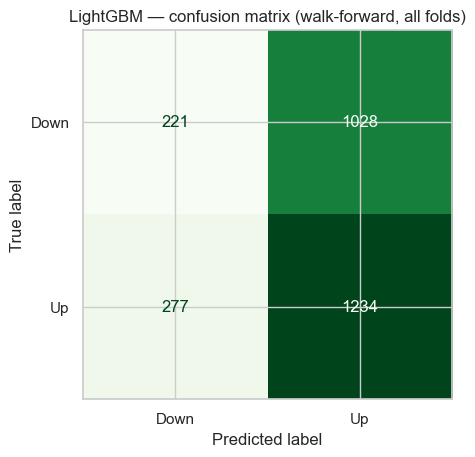

Predicted 'Up' share: 0.82
Actual    'Up' share: 0.547


In [10]:
# Collect predictions across all folds, then build one confusion matrix over everything
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    y_tr_cls = (y_tr > 0).astype(int)
    y_te_cls = (y_te > 0).astype(int)
    m = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr_cls)
    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(m.predict(X_te).tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Greens", colorbar=False)
plt.title("LightGBM — confusion matrix (walk-forward, all folds)")
plt.show()

# Same check as XGBoost: predicted vs actual "up" share
print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

Same behaviour as XGBoost: the model leans heavily toward predicting "up" and rarely calls a down day. Two independent libraries default to the majority class — further confirmation there's no directional signal to learn.

In [11]:
# Single-split reference for comparison with the walk-forward result above
# (one split = one number; walk-forward is the more reliable estimate)
y_train_cls = (y_train > 0).astype(int)
y_test_cls = (y_test > 0).astype(int)

model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train_cls)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test_cls, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5309


In [12]:
# Single-split fit used for the prediction plot below (walk-forward gives metrics, not a single prediction series)
y_train_cls = (y_train > 0).astype(int)
y_test_cls = (y_test > 0).astype(int)

model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
model.fit(X_train, y_train_cls)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test_cls, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5324


In [13]:
# Baseline: fraction of "up" days = accuracy you'd get by always predicting "up"
baseline_accuracy = y_test_cls.mean()
print(f"Accuracy (always up): {baseline_accuracy:.4f}")

Accuracy (always up): 0.5354


## Transformer (sequence model)

Unlike the tree models (which see one day at a time), the Transformer takes a **10-day window** of returns and predicts the next day.
Sequencing the data: each sample is 10 consecutive days of features, with the following day's SPY return as the target (later thresholded into up/down).

In [14]:
SEQ_LEN = 10  # number of past days the model sees at once

X_values = X.values
y_values = y.values

# Build sliding windows: each sample = SEQ_LEN consecutive days, target = the day right after the window
X_seq = []
y_seq = []
for i in range(len(X_values) - SEQ_LEN):
    window_X = X_values[i : i + SEQ_LEN]
    target_y = y_values[i + SEQ_LEN]
    X_seq.append(window_X)
    y_seq.append(target_y)

# Force a contiguous float32 array — otherwise torch.tensor() converts element-by-element and is very slow
X_seq = np.asarray(X_seq, dtype=np.float32)
y_seq = np.asarray(y_seq, dtype=np.float32)

# Same time-ordered split as before (no shuffling)
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    shuffle=False
)

In [15]:
class StockTransformer(nn.Module):
    """Transformer encoder for sequence prediction.

    Takes a window of SEQ_LEN days (each with `num_features` stock returns) and
    outputs a single value, later thresholded into an up/down decision.
    """

    def __init__(self, num_features, seq_len=SEQ_LEN, d_model=64, nhead=4, num_layers=2):
        """
        Args:
            num_features: number of input features per day (here: 12 stocks).
            seq_len: length of the input window (number of past days).
            d_model: internal embedding dimension.
            nhead: number of attention heads (must divide d_model).
            num_layers: number of stacked encoder layers.
        """
        super(StockTransformer, self).__init__()

        # Project the raw features of each day up to the model's embedding dimension
        self.input_layer = nn.Linear(num_features, d_model)

        # Learned positional encoding: without it, attention is order-agnostic and the
        # model couldn't tell day 1 from day 10 — essential for time-series data
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dim_feedforward=128,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Map the encoded sequence to a single output
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):
        """Run one forward pass; returns one value per sample."""
        x = self.input_layer(x)
        x = x + self.pos_embedding          # inject day-order information
        x = self.transformer_encoder(x)
        x = x[:, -1, :]                     # use the last day's representation as the summary
        out = self.output_layer(x)
        return out.squeeze()


num_features = X_train_seq.shape[2]
model = StockTransformer(num_features=num_features)
print(model)

StockTransformer(
  (input_layer): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [16]:
# StandardScaler works on 2D data, but our sequences are 3D (samples, days, features).
# Flatten to 2D, scale, then reshape back to the original 3D shape.
samples_train, seq_len, features = X_train_seq.shape
X_train_2d = X_train_seq.reshape(-1, features)

samples_test, _, _ = X_test_seq.shape
X_test_2d = X_test_seq.reshape(-1, features)

# Fit on train only, apply to test — prevents test-set information leaking into scaling
scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Restore the (samples, days, features) shape the Transformer expects
X_train_seq_scaled = X_train_scaled_2d.reshape(samples_train, seq_len, features)
X_test_seq_scaled = X_test_scaled_2d.reshape(samples_test, seq_len, features)

In [17]:
BATCH_SIZE = 32

# Reproducibility: fix seeds so the Transformer gives the same result each run
torch.manual_seed(42)
np.random.seed(42)

# Tensors from the SCALED sequences; labels thresholded to up(1)/down(0)
X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

y_train_seq_cls = (y_train_seq > 0).astype(np.float32)
y_test_seq_cls = (y_test_seq > 0).astype(np.float32)
y_train_t_cls = torch.tensor(y_train_seq_cls)
y_test_t_cls = torch.tensor(y_test_seq_cls)

train_dataset = TensorDataset(X_train_t, y_train_t_cls)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t_cls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = StockTransformer(num_features=features)
criterion = nn.BCEWithLogitsLoss()   # combines sigmoid + binary cross-entropy; expects raw logits
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 8

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    correct_preds = 0
    total_preds = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X).squeeze()
        targets = batch_y.float().squeeze()

        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # logit > 0 ⇔ probability > 0.5 ⇔ predicted "up"
        predicted_classes = (predictions > 0).float()
        correct_preds += (predicted_classes == targets).sum().item()
        total_preds += targets.size(0)

    avg_loss = epoch_loss / len(train_loader)
    epoch_acc = correct_preds / total_preds

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Accuracy: {epoch_acc:.4f}")

model.eval()
correct_preds_test = 0
total_preds_test = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X).squeeze()
        targets = batch_y.float().squeeze()
        predicted_classes = (predictions > 0).float()
        correct_preds_test += (predicted_classes == targets).sum().item()
        total_preds_test += targets.size(0)

test_accuracy = correct_preds_test / total_preds_test
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Epoch [1/8] | Accuracy: 0.5210
Epoch [5/8] | Accuracy: 0.5452
Final Test Accuracy: 0.5401


### Transformer — Optuna tuning

Same nested-run setup as the tree models: each trial is scored on the full walk-forward and logged to MLflow.
Fewer trials here (10) because every trial trains 5 models. Tuning `d_model`, `nhead`, `num_layers` and learning rate — but with no signal in the data, even the best configuration won't beat the baseline.

In [18]:
X_all = X.values
y_all = y.values


def transformer_objective(trial):
    """One Optuna trial for the Transformer: full walk-forward, returns mean edge over baseline."""
    EPOCHS = 8
    BATCH_SIZE = 32
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    d_model = trial.suggest_categorical("d_model", [32, 64])
    nhead = trial.suggest_categorical("nhead", [2, 4])   # must divide d_model — both options here do
    num_layers = trial.suggest_int("num_layers", 1, 3)

    diffs = []
    for train_idx, test_idx in tscv.split(X_all):
        # Scale and sequence inside each fold (fit on train part only — no leakage)
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_all[train_idx])
        X_te_scaled = scaler.transform(X_all[test_idx])
        y_tr_raw, y_te_raw = y_all[train_idx], y_all[test_idx]

        def make_seq(Xv, yv):
            """Turn a 2D returns array into (window, next-day-target) pairs of length SEQ_LEN."""
            Xs, ys = [], []
            for i in range(len(Xv) - SEQ_LEN):
                Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
            return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

        X_tr_seq, y_tr_seq = make_seq(X_tr_scaled, y_tr_raw)
        X_te_seq, y_te_seq = make_seq(X_te_scaled, y_te_raw)
        y_tr_cls = (y_tr_seq > 0).astype(np.float32)
        y_te_cls = (y_te_seq > 0).astype(np.float32)

        tr_loader = DataLoader(TensorDataset(
            torch.tensor(X_tr_seq), torch.tensor(y_tr_cls)), batch_size=BATCH_SIZE, shuffle=False)

        # Fresh model each fold so it doesn't carry over learning from earlier periods
        model = StockTransformer(num_features=X_tr_seq.shape[2], d_model=d_model, nhead=nhead, num_layers=num_layers)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        model.train()
        for _ in range(EPOCHS):
            for bx, by in tr_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx).squeeze(), by.float().squeeze())
                loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_cls = (model(torch.tensor(X_te_seq)).squeeze() > 0).float().numpy()
        diffs.append(accuracy_score(y_te_cls, pred_cls) - y_te_cls.mean())

    mean_diff = float(np.mean(diffs))
    with mlflow.start_run(run_name=f"transformer_trial_{trial.number}", nested=True):
        mlflow.set_tag("model", "transformer_optuna")
        mlflow.log_params(dict(lr=lr, d_model=d_model, nhead=nhead, num_layers=num_layers, epochs=EPOCHS))
        mlflow.log_metric("mean_diff", mean_diff)
    return mean_diff

with mlflow.start_run(run_name="transformer_optuna_study"):
    study_tf = optuna.create_study(direction="maximize")
    study_tf.optimize(transformer_objective, n_trials=10)

[I 2026-06-19 21:02:54,090] A new study created in memory with name: no-name-528ab7a8-0018-431c-99b2-6ea1a5db5cb7
[I 2026-06-19 21:02:57,383] Trial 0 finished with value: -0.015129161067306995 and parameters: {'lr': 0.0006057298914207605, 'd_model': 64, 'nhead': 2, 'num_layers': 1}. Best is trial 0 with value: -0.015129161067306995.
[I 2026-06-19 21:03:01,015] Trial 1 finished with value: -0.019188201054930687 and parameters: {'lr': 0.004019415994194168, 'd_model': 32, 'nhead': 4, 'num_layers': 1}. Best is trial 0 with value: -0.015129161067306995.
[I 2026-06-19 21:03:10,818] Trial 2 finished with value: -0.03247232362627983 and parameters: {'lr': 0.004904597941643699, 'd_model': 32, 'nhead': 4, 'num_layers': 3}. Best is trial 0 with value: -0.015129161067306995.
[I 2026-06-19 21:03:16,016] Trial 3 finished with value: -0.016236167401075363 and parameters: {'lr': 0.003975122049065685, 'd_model': 32, 'nhead': 2, 'num_layers': 2}. Best is trial 0 with value: -0.015129161067306995.
[I 202

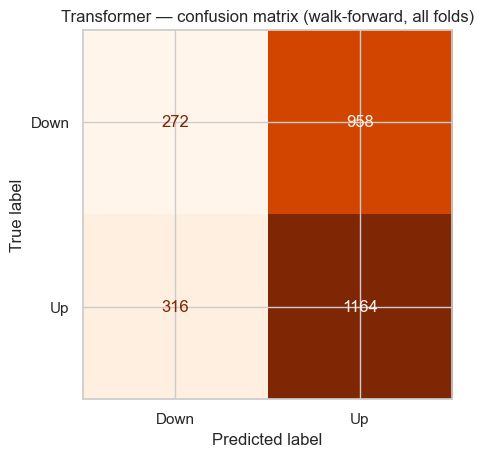

Predicted 'Up' share: 0.783
Actual    'Up' share: 0.546


In [19]:
# Confusion matrix for the Transformer, aggregated across all walk-forward folds
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X_all):
    # Scale and sequence inside each fold (fit on train part only — no leakage)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_all[train_idx])
    X_te_scaled = scaler.transform(X_all[test_idx])
    y_tr_raw, y_te_raw = y_all[train_idx], y_all[test_idx]

    def make_seq(Xv, yv):
        """Turn a 2D returns array into (window, next-day-target) pairs of length SEQ_LEN."""
        Xs, ys = [], []
        for i in range(len(Xv) - SEQ_LEN):
            Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
        return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

    X_tr_seq, y_tr_seq = make_seq(X_tr_scaled, y_tr_raw)
    X_te_seq, y_te_seq = make_seq(X_te_scaled, y_te_raw)
    y_tr_cls = (y_tr_seq > 0).astype(np.float32)
    y_te_cls = (y_te_seq > 0).astype(np.float32)

    tr_loader = DataLoader(TensorDataset(
        torch.tensor(X_tr_seq), torch.tensor(y_tr_cls)), batch_size=32, shuffle=False)

    # Fresh model each fold so it doesn't carry over learning from earlier periods
    model = StockTransformer(num_features=X_tr_seq.shape[2])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    model.train()
    for _ in range(15):
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx).squeeze(), by.float().squeeze())
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_cls = (model(torch.tensor(X_te_seq)).squeeze() > 0).float().numpy()  # logit > 0 ⇒ "up"

    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(pred_cls.tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Oranges", colorbar=False)
plt.title("Transformer — confusion matrix (walk-forward, all folds)")
plt.show()

print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

The Transformer spreads its predictions a bit more than the trees, but still without real directional skill — the up/down split roughly mirrors the class balance rather than tracking actual moves.

## Conclusion

Across all three models, 5-fold walk-forward, and Optuna tuning, **none beats the "always up" baseline** by a meaningful margin — fold-to-fold differences hover around zero and the best tuned result is well within noise (std ≈ 10× the mean edge).
The confusion matrices show why: the models mostly default to the majority class instead of detecting direction.
Next-day SPY direction is not predictable from same-day constituent returns — consistent with weak-form market efficiency. The limitation is the data, not the models or their hyperparameters.